In [1]:
# Core libraries
import os
import json
from collections import Counter

# Data handling
import pandas as pd
from datasets import load_dataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter 
# Display settings
pd.set_option('display.max_colwidth', 500)
sns.set(style="whitegrid")


c:\Users\ASUS\Desktop\ING5\Traitement autom\fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

data_dir = "../data" 

# Domains
domains = [
    "phishing",
    "fake_news",
    "political_statements",  
    "product_reviews",
    "job_scams",
    "sms",
    "twitter_rumours"
]

# File names
splits = ["train.jsonl", "validation.jsonl", "test.jsonl"]


In [3]:
def load_jsonl(filepath):
    """Load a .jsonl file into a pandas DataFrame"""
    data = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)


In [4]:
domain_name = "phishing"
domain_path = os.path.join(data_dir, domain_name)

train_df = load_jsonl(os.path.join(domain_path, "train.jsonl"))
val_df = load_jsonl(os.path.join(domain_path, "validation.jsonl"))
test_df = load_jsonl(os.path.join(domain_path, "test.jsonl"))
all_df = pd.concat([train_df, val_df, test_df])

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"All shape: {all_df.shape}")


Train shape: (12217, 2)
Validation shape: (1527, 2)
Test shape: (1528, 2)
All shape: (15272, 2)


In [5]:
summary = []

for domain in domains:
    train_path = os.path.join(data_dir, domain, "train.jsonl")
    
    if not os.path.exists(train_path):
        print(f"⚠️ Skipping {domain} — file not found at {train_path}")
        continue

    train_df = load_jsonl(train_path)
    
    n_samples = len(train_df)
    n_deceptive = train_df['label'].sum()
    n_non_deceptive = n_samples - n_deceptive
    avg_len = train_df['text'].apply(len).mean()
    
    summary.append({
        "domain": domain,
        "total_samples": n_samples,
        "deceptive": n_deceptive,
        "non_deceptive": n_non_deceptive,
        "avg_text_length": round(avg_len, 2)
    })

summary_df = pd.DataFrame(summary)
summary_df

,domain,total_samples,deceptive,non_deceptive,avg_text_length
0,phishing,12217,4859,7358,2284.10
1,fake_news,16364,7065,9299,3369.66
2,political_statements,9997,6433,3564,106.47
3,product_reviews,16776,8393,8383,361.86
4,job_scams,11436,479,10957,1245.90
5,sms,5259,1019,4240,84.83
6,twitter_rumours,4631,1575,3056,118.03


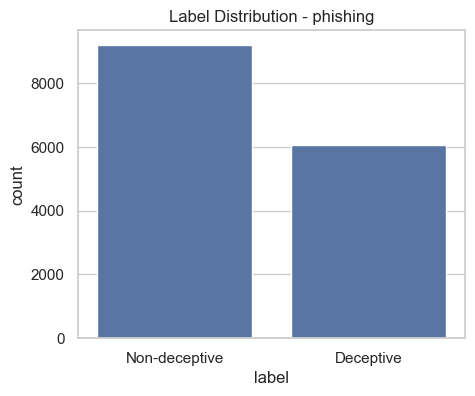

label
0    3056
1    1575
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=all_df)
plt.xticks([0,1], ['Non-deceptive', 'Deceptive'])
plt.title(f"Label Distribution - {domain_name}")
plt.show()

train_df['label'].value_counts()


count     15272.000000
mean       2260.787389
std        9765.023192
min           6.000000
25%         538.000000
50%        1007.000000
75%        2077.000000
max      999999.000000
Name: text_len, dtype: float64


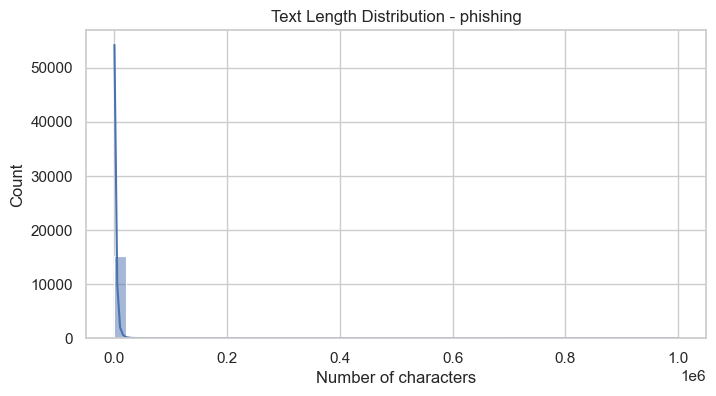

In [7]:
all_df['text_len'] = all_df['text'].apply(len)

# Summary stats
print(all_df['text_len'].describe())

# Histogram
plt.figure(figsize=(8,4))
sns.histplot(all_df['text_len'], bins=50, kde=True)
plt.title(f"Text Length Distribution - {domain_name}")
plt.xlabel("Number of characters")
plt.show()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


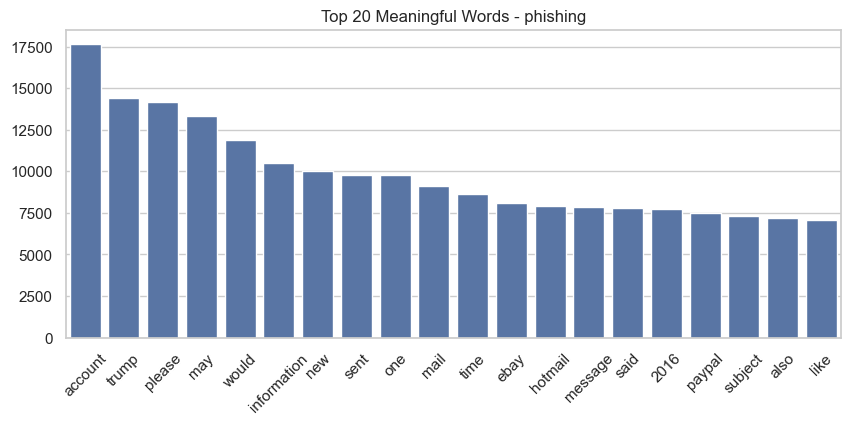

In [8]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import nltk

# Download stopwords list (only once)
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
custom_stopwords = {"com", "www", "https", "email", "click" , "http"}
stop_words |= custom_stopwords

def tokenize(text):
    # Extract words and filter stopwords + very short tokens
    tokens = re.findall(r'\b\w+\b', text.lower())
    return [t for t in tokens if t not in stop_words and len(t) > 2]

all_tokens = [token for text in all_df['text'] for token in tokenize(text)]
word_counts = Counter(all_tokens)
common_words = word_counts.most_common(20)

# Plot
words, counts = zip(*common_words)
plt.figure(figsize=(10,4))
sns.barplot(x=list(words), y=list(counts))
plt.xticks(rotation=45)
plt.title(f"Top 20 Meaningful Words - {domain_name}")
plt.show()


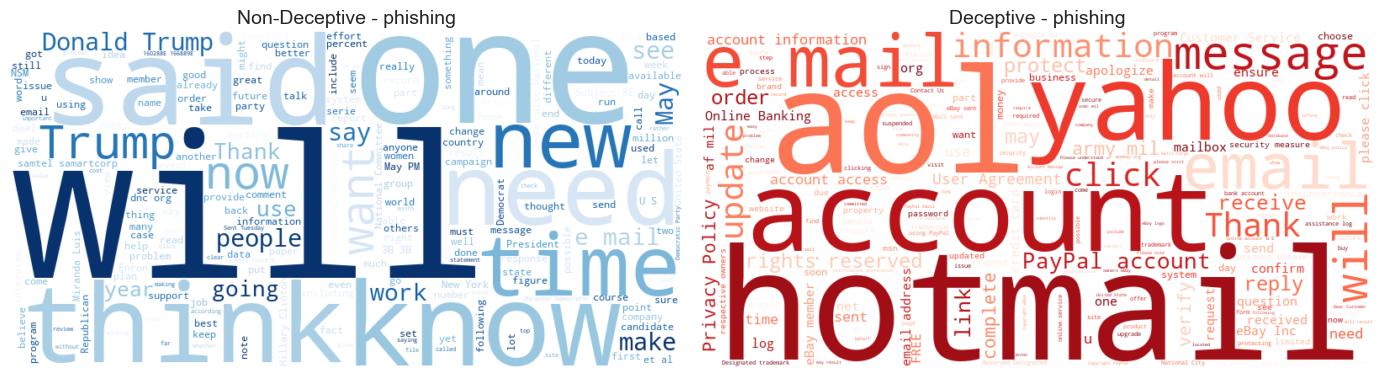

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate text by label
deceptive_texts = " ".join(all_df[all_df["label"] == 1]["text"].tolist())
non_deceptive_texts = " ".join(all_df[all_df["label"] == 0]["text"].tolist())

# Create word clouds
wc_deceptive = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(deceptive_texts)
wc_non_deceptive = WordCloud(width=800, height=400, background_color="white", colormap="Blues").generate(non_deceptive_texts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(wc_non_deceptive, interpolation="bilinear")
axes[0].set_title(f"Non-Deceptive - {domain_name}", fontsize=14)
axes[0].axis("off")

axes[1].imshow(wc_deceptive, interpolation="bilinear")
axes[1].set_title(f"Deceptive - {domain_name}", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()


label
Non-deceptive    491.734290
Deceptive        209.467402
Name: word_count, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7784\3342607787.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Non-deceptive", "Deceptive"], y=avg_wc.values, palette="viridis")


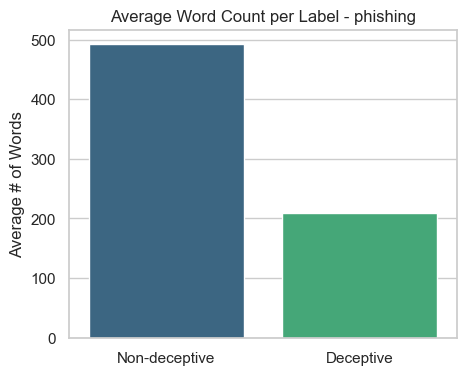

In [10]:
# Function to count words
def word_count(text):
    return len(re.findall(r'\b\w+\b', text))

all_df["word_count"] = all_df["text"].apply(word_count)

# Compute averages
avg_wc = all_df.groupby("label")["word_count"].mean().rename({0: "Non-deceptive", 1: "Deceptive"})
print(avg_wc)

# Visualize
plt.figure(figsize=(5,4))
sns.barplot(x=["Non-deceptive", "Deceptive"], y=avg_wc.values, palette="viridis")
plt.title(f"Average Word Count per Label - {domain_name}")
plt.ylabel("Average # of Words")
plt.show()


Vocabulary Richness (Non-deceptive): 0.0209
Vocabulary Richness (Deceptive): 0.0490


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7784\673888575.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Non-deceptive", "Deceptive"], y=[non_dec_rich, dec_rich], palette="coolwarm")


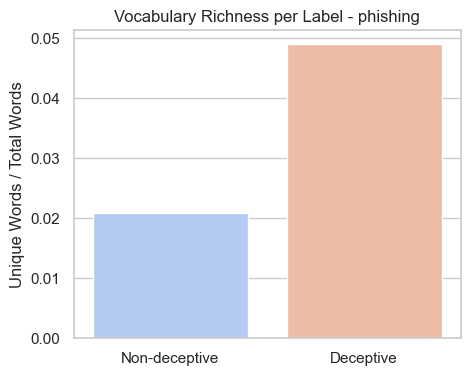

In [11]:
# Compute vocabulary richness
def vocab_richness(texts):
    all_words = re.findall(r'\b\w+\b', " ".join(texts).lower())
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if len(all_words) > 0 else 0

non_dec_rich = vocab_richness(all_df[all_df["label"] == 0]["text"])
dec_rich = vocab_richness(all_df[all_df["label"] == 1]["text"])

print(f"Vocabulary Richness (Non-deceptive): {non_dec_rich:.4f}")
print(f"Vocabulary Richness (Deceptive): {dec_rich:.4f}")

# Plot
plt.figure(figsize=(5,4))
sns.barplot(x=["Non-deceptive", "Deceptive"], y=[non_dec_rich, dec_rich], palette="coolwarm")
plt.title(f"Vocabulary Richness per Label - {domain_name}")
plt.ylabel("Unique Words / Total Words")
plt.show()

VADER’s compound score ∈ [–1, 1]:
 - score > 0.05 → Positive
 - score < –0.05 → Negative
 - Otherwise → Neutral

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (only once)
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
def get_sentiment_scores(text):
    scores = sia.polarity_scores(text)
    return scores["compound"]

all_df["sentiment"] = all_df["text"].apply(get_sentiment_scores)

# Summary
print(all_df.groupby("label")["sentiment"].describe())

# Visualization
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="sentiment", data=all_df, palette="coolwarm")
plt.xticks([0,1], ["Non-deceptive", "Deceptive"])
plt.title(f"Sentiment Polarity per Label - {domain_name}")
plt.ylabel("Compound Sentiment Score")
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


If deceptive messages cluster more in positive (fake praise) or negative (fear tactics) tones — that’s linguistic evidence of manipulation patterns.

In [ ]:
import textstat
import numpy as np
# Pronouns & punctuation counts
def linguistic_features(text):
    features = {}
    text_lower = text.lower()
    
    # Pronouns
    features['i_count'] = text_lower.count(' i ')
    features['we_count'] = text_lower.count(' we ')
    features['you_count'] = text_lower.count(' you ')
    
    # Punctuation
    features['exclamations'] = text.count('!')
    features['questions'] = text.count('?')
    
    # Sentence length
    sentences = re.split(r'[.!?]', text)
    sentences = [s for s in sentences if s.strip()]
    features['avg_sentence_len'] = np.mean([len(s.split()) for s in sentences]) if sentences else 0
    
    # Readability
    features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
    features['flesch_kincaid_grade'] = textstat.flesch_kincaid_grade(text)
    
    return features

# Apply to train set
style_feats = all_df['text'].apply(linguistic_features).apply(pd.Series)
all_df = pd.concat([all_df, style_feats], axis=1)

# Quick overview
print(all_df.groupby('label')[['i_count','we_count','you_count','exclamations','questions','avg_sentence_len','flesch_reading_ease','flesch_kincaid_grade']].mean())


In [ ]:
style_cols = ['i_count','we_count','you_count','exclamations','questions','avg_sentence_len','flesch_reading_ease','flesch_kincaid_grade']

plt.figure(figsize=(12,8))
for i, col in enumerate(style_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(x='label', y=col, data=train_df, palette="Set3")
    plt.xticks([0,1], ['Non-deceptive','Deceptive'])
    plt.title(col)
plt.tight_layout()
plt.show()
